# Dataset

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# 2D OU Dataset
# x0 ~ N(mu0, 2I)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim = 2

mu0_np = np.array([10.0, 10.0], dtype=np.float32)
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(2.0)

t = 5.0
N = 10000

# x0 ~ N(mu0, var0 I)
x0_np = (
    np.random.randn(N, dim).astype(np.float32) * std0
    + mu0_np
)

# OU conditional mean and variance
a_t = np.exp(-beta * t)

cond_var_t = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * t))
)

cond_std_t = np.sqrt(cond_var_t)

# xt | x0
eps_np = np.random.randn(N, dim).astype(np.float32)

xt_np = (
    a_t * x0_np
    + cond_std_t * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t_np = a_t * mu0_np

var_t = (
    (a_t**2) * var0
    + cond_var_t
)

# exact marginal score
score_t_np = (
    -(xt_np - mu_t_np)
    / var_t
).astype(np.float32)

# conditional score
cond_score_np = (
    -(xt_np - a_t * x0_np)
    / cond_var_t
).astype(np.float32)

# torch tensors
mu0 = torch.tensor(mu0_np, device=device)

x0_train = torch.tensor(x0_np, device=device)
xt_train = torch.tensor(xt_np, device=device)
score_t_train = torch.tensor(score_t_np, device=device)
cond_score_train = torch.tensor(cond_score_np, device=device)

print("mu_t =", mu_t_np)
print("var_t =", var_t)
print("conditional variance =", cond_var_t)
print("xt empirical mean =", xt_np.mean(axis=0))
print("xt empirical var =", xt_np.var(axis=0))
print("x0_train shape =", x0_train.shape)
print("xt_train shape =", xt_train.shape)

mu_t = [0.06737947 0.06737947]
var_t = 1.0000453999297627
conditional variance = 0.9999546000702377
xt empirical mean = [0.07648762 0.08930727]
xt empirical var = [0.9963872 0.9870275]
x0_train shape = torch.Size([10000, 2])
xt_train shape = torch.Size([10000, 2])


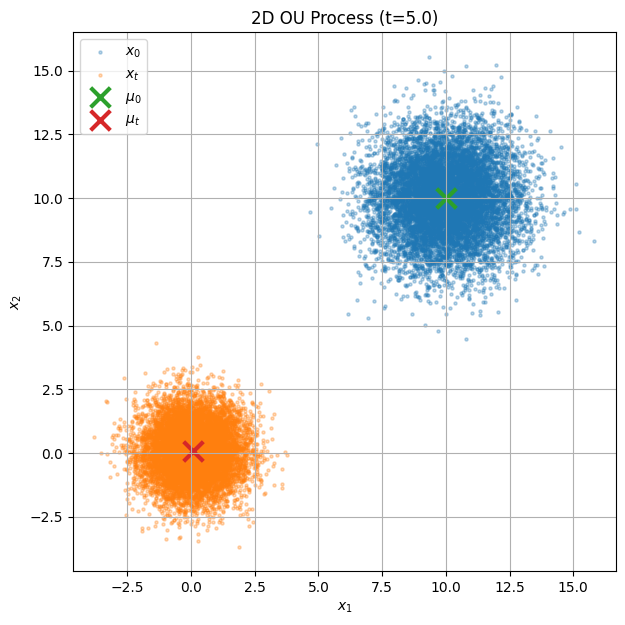

In [2]:
plt.figure(figsize=(7,7))

plt.scatter(
    x0_np[:,0],
    x0_np[:,1],
    s=5,
    alpha=0.3,
    label=r"$x_0$"
)

plt.scatter(
    xt_np[:,0],
    xt_np[:,1],
    s=5,
    alpha=0.3,
    label=r"$x_t$"
)

plt.scatter(
    mu0_np[0],
    mu0_np[1],
    marker="x",
    s=200,
    linewidths=3,
    label=r"$\mu_0$"
)

plt.scatter(
    mu_t_np[0],
    mu_t_np[1],
    marker="x",
    s=200,
    linewidths=3,
    label=r"$\mu_t$"
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(f"2D OU Process (t={t})")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

In [3]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x, t):

        inp = torch.cat([x, t], dim=1)

        return self.net(inp)


model = ScoreNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)


In [4]:
x_test = torch.randn(4, 2).to(device)
t_test = torch.rand(4, 1).to(device)

y = model(x_test, t_test)

print(y.shape)

torch.Size([4, 2])


# Training

In [5]:
import copy

# ============================================================
# 2D Time-dependent OU training
# with ESM / ISM / DSM / I_DSM
# ============================================================

T = 5.0
eps_t = 0.05

epochs = 300
batch_size = 2048

save_epochs = [50, 100, 150, 200, 250, 300]
saved_models = {}

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(1, epochs + 1):

    # sample x0 ~ N(mu0, 2I)
    x0 = (
        torch.randn(batch_size, dim, device=device)
        * np.sqrt(var0)
        + mu0
    )

    # sample t ~ Uniform(eps_t, T)
    t_batch = (
        eps_t
        + (T - eps_t)
        * torch.rand(batch_size, 1, device=device)
    )

    # OU coefficients
    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # generate xt
    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # marginal distribution p_t(x)
    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # exact marginal score
    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # conditional score
    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # network prediction
    pred_score = model(xt, t_batch)

    # 1. L_ESM
    L_ESM = (
        (pred_score - score_t)**2
    ).sum(dim=1).mean()

    # 2. L_ISM
    div_score = 0

    for j in range(dim):

        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=xt,
            create_graph=True,
            retain_graph=True
        )[0][:, j]

        div_score = div_score + grad_j

    L_ISM = (
        (pred_score**2).sum(dim=1)
        + 2 * div_score
    ).mean()

    # 3. L_DSM
    L_DSM = (
        (pred_score - cond_score)**2
    ).sum(dim=1).mean()

    # 4. Indicator I_DSM
    I_DSM = (
        (pred_score**2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    # train
    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # record
    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # save model
    if epoch in save_epochs:
        saved_models[epoch] = copy.deepcopy(model.state_dict())

    # print
    if epoch in save_epochs or epoch % 50 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch   50 | L_ESM = 0.51723278 | L_ISM = -1.32072210 | L_DSM = 1.08877921 | I_DSM = -0.05118759
Epoch  100 | L_ESM = 0.22342409 | L_ISM = -1.61641765 | L_DSM = 0.91028106 | I_DSM = -0.04186983
Epoch  150 | L_ESM = 0.13420263 | L_ISM = -1.71218371 | L_DSM = 0.73171300 | I_DSM = -0.03205209
Epoch  200 | L_ESM = 0.07323141 | L_ISM = -1.76388907 | L_DSM = 0.58216178 | I_DSM = -0.02582997
Epoch  250 | L_ESM = 0.03515830 | L_ISM = -1.83243406 | L_DSM = 0.65044898 | I_DSM = -0.03281999
Epoch  300 | L_ESM = 0.01747856 | L_ISM = -1.86908805 | L_DSM = 0.51421034 | I_DSM = -0.01635457


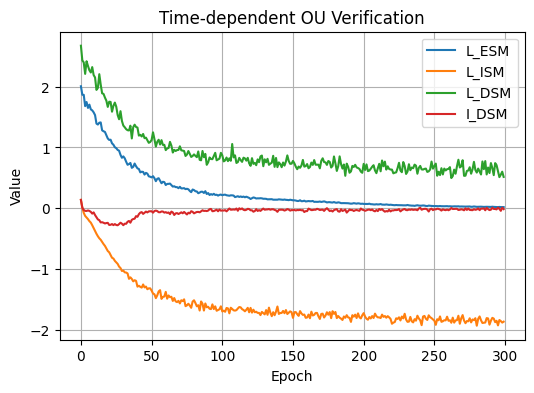

In [6]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Reverse

In [7]:
import numpy as np
import torch
import pandas as pd

# ============================================================
# 2D Reverse OU Sampling: compare steps / dt with fixed T
# ============================================================

model.eval()

num_samples = 5000

T = 5.0
beta = 1.0
var0 = 2.0
sigma = np.sqrt(2.0)

step_list = [500, 1000, 2000, 5000]

results = []
sample_dict = {}

mu0_cpu = mu0.detach().cpu().numpy()
target_std = np.sqrt(var0)

for steps in step_list:

    dt = T / steps

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * T))
    )

    mu_T = a_T * mu0

    var_T = (
        (a_T**2) * var0
        + cond_var_T
    )

    x = (
        torch.randn(num_samples, dim, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones(num_samples, 1, device=device) * t_now

            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy()
    sample_dict[steps] = samples_reverse

    reverse_mean = samples_reverse.mean(axis=0)
    reverse_std = samples_reverse.std(axis=0)

    results.append({
        "steps": steps,
        "dt": dt,
        "steps*dt": steps * dt,

        "mean_x1": reverse_mean[0],
        "mean_x2": reverse_mean[1],
        "std_x1": reverse_std[0],
        "std_x2": reverse_std[1],

        "target_mean_x1": mu0_cpu[0],
        "target_mean_x2": mu0_cpu[1],
        "target_std": target_std,

        "mean_error_norm": np.linalg.norm(reverse_mean - mu0_cpu),
        "std_error_norm": np.linalg.norm(reverse_std - target_std),
    })

df_results = pd.DataFrame(results)
df_results

,steps,dt,steps*dt,mean_x1,mean_x2,std_x1,std_x2,target_mean_x1,target_mean_x2,target_std,mean_error_norm,std_error_norm
0,500,0.0100,5.0,9.819386,9.808701,2.142871,2.408267,10.0,10.0,1.414214,0.263091,1.232511
1,1000,0.0050,5.0,9.807183,9.793113,2.665846,3.119564,10.0,10.0,1.414214,0.282808,2.115373
2,2000,0.0025,5.0,9.859887,9.834473,1.998858,2.238772,10.0,10.0,1.414214,0.216866,1.010794
3,5000,0.0010,5.0,9.834086,9.868564,2.439363,2.794955,10.0,10.0,1.414214,0.211667,1.719703


,steps,dt,steps*dt,loss_eval_t,mean_x1,mean_x2,std_x1,std_x2,mean_error_norm,std_error_norm,L_ESM,L_DSM,L_ISM,I_DSM
0,500,0.0100,5.0,1.0,9.798963,9.788374,2.544777,2.908169,0.291893,1.873520,0.018556,0.574970,-1.748922,-0.111589
1,1000,0.0050,5.0,1.0,9.776147,9.753614,3.894202,4.559191,0.332890,4.005150,0.018556,0.567615,-1.748922,-0.100381
2,2000,0.0025,5.0,1.0,9.834844,9.831039,2.329943,2.679337,0.236272,1.561761,0.018556,0.569955,-1.748922,-0.100450
3,5000,0.0010,5.0,1.0,9.736258,9.694523,8.843886,10.695278,0.403579,11.888574,0.018556,0.571049,-1.748922,-0.101684


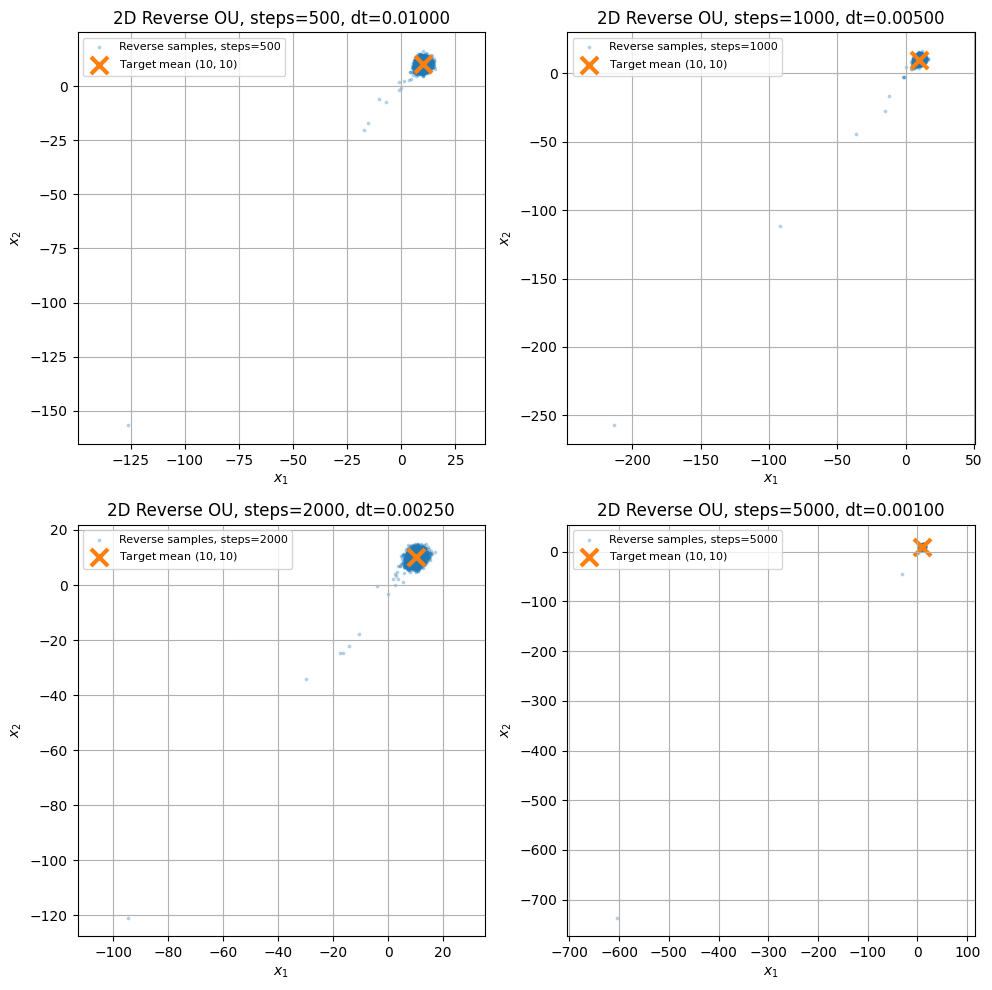

In [8]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2D Reverse OU Sampling + Indicators
# compare steps / dt with fixed T
# ============================================================

model.eval()
device = next(model.parameters()).device

dim = 2
num_samples = 5000
num_eval = 10000

T = 5.0
beta = 1.0
var0 = 2.0
std0 = np.sqrt(var0)
sigma = np.sqrt(2.0)

mu0 = torch.tensor([10.0, 10.0], device=device)
mu0_cpu = mu0.detach().cpu().numpy()

step_list = [500, 1000, 2000, 5000]
t_eval_for_loss = 1.0


# ============================================================
# Helper: OU marginal parameters
# ============================================================

def ou_params(t):
    a_t = np.exp(-beta * t)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    return a_t, cond_var_t, mu_t, var_t


# ============================================================
# Helper: calculate 2D losses
# ============================================================

def compute_losses(model, x_eval, t_now):

    x_eval = x_eval.clone().detach().requires_grad_(True)
    t_tensor = torch.ones(x_eval.shape[0], 1, device=device) * t_now

    pred_score = model(x_eval, t_tensor)

    a_t, cond_var_t, mu_t, var_t = ou_params(t_now)

    # marginal score
    marginal_score = -(x_eval - mu_t) / var_t

    # posterior x0 | xt
    post_mean = (
        mu0
        + (a_t * var0 / var_t)
        * (x_eval - mu_t)
    )

    post_var = (
        var0
        - (a_t**2 * var0**2) / var_t
    )

    x0_post = (
        post_mean
        + torch.sqrt(torch.tensor(post_var, device=device, dtype=x_eval.dtype))
        * torch.randn_like(post_mean)
    )

    # conditional score
    cond_score = -(x_eval - a_t * x0_post) / cond_var_t

    # ESM
    L_ESM = (
        (pred_score - marginal_score) ** 2
    ).sum(dim=1).mean()

    # DSM
    L_DSM = (
        (pred_score - cond_score) ** 2
    ).sum(dim=1).mean()

    # ISM divergence
    div_score = 0

    for j in range(dim):
        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=x_eval,
            create_graph=False,
            retain_graph=True
        )[0][:, j]

        div_score = div_score + grad_j

    L_ISM = (
        (pred_score ** 2).sum(dim=1)
        + 2 * div_score
    ).mean()

    # DSM indicator
    I_DSM = (
        (pred_score ** 2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    return {
        "L_ESM": L_ESM.item(),
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }


# ============================================================
# Fixed evaluation data for indicators
# ============================================================

a_eval, cond_var_eval, mu_eval, var_eval = ou_params(t_eval_for_loss)

x_eval_for_loss = (
    torch.randn(num_eval, dim, device=device)
    * np.sqrt(var_eval)
    + mu_eval
)


# ============================================================
# Main experiment
# ============================================================

results = []
sample_dict = {}

for steps in step_list:

    dt = T / steps

    # start from p_T
    a_T, cond_var_T, mu_T, var_T = ou_params(T)

    x = (
        torch.randn(num_samples, dim, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones(num_samples, 1, device=device) * t_now

            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy()
    sample_dict[steps] = samples_reverse

    reverse_mean = samples_reverse.mean(axis=0)
    reverse_std = samples_reverse.std(axis=0)

    losses = compute_losses(model, x_eval_for_loss, t_eval_for_loss)

    results.append({
        "steps": steps,
        "dt": dt,
        "steps*dt": steps * dt,
        "loss_eval_t": t_eval_for_loss,

        "mean_x1": reverse_mean[0],
        "mean_x2": reverse_mean[1],
        "std_x1": reverse_std[0],
        "std_x2": reverse_std[1],

        "mean_error_norm": np.linalg.norm(reverse_mean - mu0_cpu),
        "std_error_norm": np.linalg.norm(reverse_std - std0),

        **losses
    })


df_results = pd.DataFrame(results)
display(df_results)


# ============================================================
# Plot four 2D figures
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, steps in zip(axes, step_list):

    samples = sample_dict[steps]

    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=3,
        alpha=0.25,
        label=f"Reverse samples, steps={steps}"
    )

    ax.scatter(
        mu0_cpu[0],
        mu0_cpu[1],
        marker="x",
        s=150,
        linewidths=3,
        label=r"Target mean $(10,10)$"
    )

    ax.set_title(f"2D Reverse OU, steps={steps}, dt={T/steps:.5f}")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.axis("equal")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()